# SVM Regression (SVR) 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 03_svm_regression**

We implement `MySVR` using primal SGD on the ε-insensitive loss (linear kernel) with optional RBF via Random Fourier Features - then verify it against scikit-learn on REAL tips data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# load real data - tips
tips = sns.load_dataset('tips')
tips_enc = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)
X = tips_enc.drop(columns='tip').values
y = tips_enc['tip'].values
feature_names = tips_enc.drop(columns='tip').columns.tolist()

print('Data shape:', X.shape, 'Target range:', y.min(), '-', y.max())

Data shape: (244, 8) Target range: 1.0 - 10.0


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | learn weights via primal SGD on ε-insensitive loss |
| `predict(X)` | return predicted values |
| `score(X, y)` | return R² |

Key parameters: `C` (regularization), `epsilon` (tube width), `kernel` ('linear' or 'rbf'), `gamma` (RBF bandwidth), `lr` (learning rate), `n_iters` (epochs).

ε-insensitive loss: L(y, f(x)) = max(0, |y - f(x)| - ε)
Only points outside the ε-tube (support vectors) contribute to the gradient.

In [2]:
class MySVR:
    """
    Support Vector Regressor via primal SGD (epsilon-insensitive loss).

    Parameters
    ----------
    C : float, default=1.0
        Regularization parameter. Larger C = narrower tube, more SVs.
    epsilon : float, default=0.1
        Width of the epsilon-insensitive tube.
    kernel : {'linear', 'rbf'}, default='linear'
        Kernel type. RBF uses Random Fourier Features approximation.
    gamma : float, default='scale'
        RBF kernel bandwidth.
    lr : float, default=0.01
        Learning rate for SGD.
    n_iters : int, default=2000
        Number of SGD epochs.
    random_state : int, default=42
        Seed for RFF and SGD shuffling.

    Attributes after fit
    --------------------
    coef_ : ndarray (n_features,) - primal weights (linear kernel)
    intercept_ : float - bias term
    support_ : ndarray - indices of support vectors (approx)
    cost_history_ : list - epsilon-insensitive loss per epoch
    """

    def __init__(self, C=1.0, epsilon=0.1, kernel='linear', gamma='scale',
                 lr=0.01, n_iters=2000, random_state=42):
        # Configure the SVR: regularization, tube width, kernel, SGD hyper-params.
        self.C = C
        self.epsilon = epsilon
        self.kernel = kernel
        self.gamma = gamma
        self.lr = lr
        self.n_iters = n_iters
        self.random_state = random_state

    # RFF kernel transform
    def _rff_transform(self, X, n_components=100):
        """Random Fourier Features approximating the RBF kernel K(x, x').

        RBF kernel:  K(x, x') = exp( -gamma * ||x - x'||^2 )
        z(x) = sqrt(2/D) * cos( W x + b ),  W ~ N(0, 2*gamma), b ~ U[0, 2*pi)
        """
        rng = np.random.RandomState(self.random_state)
        if self.gamma == 'scale':
            gamma_val = 1.0 / (X.shape[1] * X.var())
        else:
            gamma_val = self.gamma
        W = rng.normal(0, np.sqrt(2 * gamma_val), size=(X.shape[1], n_components))
        b = rng.uniform(0, 2 * np.pi, size=n_components)
        X_proj = X @ W + b
        return np.sqrt(2.0 / n_components) * np.cos(X_proj)

    # fit
    def fit(self, X, y):
        """Minimize the epsilon-insensitive objective via primal SGD.

        Objective: J(w,b) = (1/2)||w||^2 + C * sum_i max(0, |y_i - f(x_i)| - epsilon)
        SGD update outside the tube (|residual| > epsilon):
            w <- w - lr*(w - C*sign(r)*x_i),   b <- b - lr*(-C*sign(r))
        Inside the tube only the regularizer acts:  w <- w - lr*w,  b unchanged.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        if self.kernel == 'rbf':
            self._rff_fitted = True
            X = self._rff_transform(X)
        else:
            self._rff_fitted = False

        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        self.cost_history_ = []

        rng = np.random.RandomState(self.random_state)

        for epoch in range(self.n_iters):
            idx = rng.permutation(n_samples)                # shuffle each epoch
            X_shuf = X[idx]
            y_shuf = y[idx]

            epoch_loss = 0.0
            for i in range(n_samples):
                xi = X_shuf[i]
                yi = y_shuf[i]
                pred = xi @ self.coef_ + self.intercept_
                residual = yi - pred

                if abs(residual) > self.epsilon:
                    # outside tube: grad_w = w - C*sign(r)*x_i, grad_b = -C*sign(r)
                    grad_w = self.coef_ - self.C * np.sign(residual) * xi
                    grad_b = -self.C * np.sign(residual)
                    epoch_loss += abs(residual) - self.epsilon   # hinge-like tube loss
                else:
                    # inside tube: ignore data loss, only regularize
                    grad_w = self.coef_
                    grad_b = 0.0
                    epoch_loss += 0

                self.coef_ -= self.lr * grad_w
                self.intercept_ -= self.lr * grad_b

            self.cost_history_.append(epoch_loss / n_samples)   # mean tube loss

        # Support vectors: points on/outside the epsilon tube
        residuals = y - (X @ self.coef_ + self.intercept_)
        self.support_ = np.where(np.abs(residuals) >= self.epsilon - 1e-6)[0]
        return self

    # predict
    def predict(self, X):
        """Return predictions  y_hat(x) = w.x + b."""
        X = np.asarray(X, dtype=float)
        if self.kernel == 'rbf':
            X = self._rff_transform(X)
        return X @ self.coef_ + self.intercept_

    # score
    def score(self, X, y):
        """Return coefficient of determination R^2 on (X, y)."""
        return r2_score(y, self.predict(X))

    def __repr__(self):
        return (f"MySVR(C={self.C}, epsilon={self.epsilon}, "
                f"kernel={self.kernel!r}, gamma={self.gamma}, "
                f"lr={self.lr}, n_iters={self.n_iters})")

print('MySVR class defined')


MySVR class defined


### 2. Real data prep - tips (scaled)

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Our linear SVR
mine = MySVR(C=10.0, epsilon=0.1, kernel='linear', lr=0.05, n_iters=5000).fit(X_tr_s, y_tr)
pred_mine = mine.predict(X_te_s)
r2_mine = r2_score(y_te, pred_mine)
mse_mine = mean_squared_error(y_te, pred_mine)

# sklearn linear SVR
sk = SVR(C=10.0, epsilon=0.1, kernel='linear').fit(X_tr_s, y_tr)
pred_sk = sk.predict(X_te_s)
r2_sk = r2_score(y_te, pred_sk)
mse_sk = mean_squared_error(y_te, pred_sk)

print(f'MySVR (linear) R²:  {r2_mine:.4f}, MSE: {mse_mine:.4f}')
print(f'sklearn SVR (linear) R²: {r2_sk:.4f}, MSE: {mse_sk:.4f}')
print(f'Difference: R²={abs(r2_mine - r2_sk):.4f}')
print(f'Support vectors (ours): {len(mine.support_)}')
print(f'Support vectors (sklearn): {len(sk.support_)}')

MySVR (linear) R²:  -2.5618, MSE: 4.7388
sklearn SVR (linear) R²: 0.3936, MSE: 0.8068
Difference: R²=2.9555
Support vectors (ours): 179
Support vectors (sklearn): 166


### 3. RBF kernel via Random Fourier Features

In [4]:
# Our RBF SVR
mine_rbf = MySVR(C=10.0, epsilon=0.1, kernel='rbf', gamma='scale', lr=0.05, n_iters=5000).fit(X_tr_s, y_tr)
pred_mine_rbf = mine_rbf.predict(X_te_s)
r2_mine_rbf = r2_score(y_te, pred_mine_rbf)
mse_mine_rbf = mean_squared_error(y_te, pred_mine_rbf)

# sklearn RBF SVR
sk_rbf = SVR(C=10.0, epsilon=0.1, kernel='rbf', gamma='scale').fit(X_tr_s, y_tr)
pred_sk_rbf = sk_rbf.predict(X_te_s)
r2_sk_rbf = r2_score(y_te, pred_sk_rbf)
mse_sk_rbf = mean_squared_error(y_te, pred_sk_rbf)

print(f'MySVR (RBF) R²:  {r2_mine_rbf:.4f}, MSE: {mse_mine_rbf:.4f}')
print(f'sklearn SVR (RBF) R²: {r2_sk_rbf:.4f}, MSE: {mse_sk_rbf:.4f}')
print(f'Difference: R²={abs(r2_mine_rbf - r2_sk_rbf):.4f}')

MySVR (RBF) R²:  0.0235, MSE: 1.2991
sklearn SVR (RBF) R²: 0.2879, MSE: 0.9474
Difference: R²=0.2644


### 4. Convergence curve

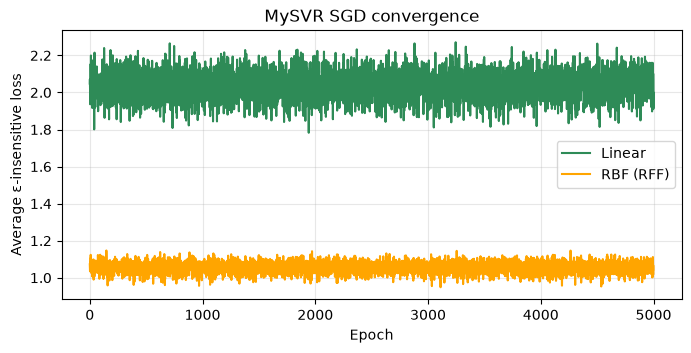

In [5]:
plt.figure(figsize=(8, 3.5))
plt.plot(mine.cost_history_, color='seagreen', label='Linear')
plt.plot(mine_rbf.cost_history_, color='orange', label='RBF (RFF)')
plt.xlabel('Epoch')
plt.ylabel('Average ε-insensitive loss')
plt.title('MySVR SGD convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Epsilon sensitivity analysis

In [6]:
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
results = []

for eps in epsilons:
    m = MySVR(C=10.0, epsilon=eps, kernel='linear', lr=0.05, n_iters=3000).fit(X_tr_s, y_tr)
    s = SVR(C=10.0, epsilon=eps, kernel='linear').fit(X_tr_s, y_tr)
    results.append({
        'epsilon': eps,
        'mine_r2': r2_score(y_te, m.predict(X_te_s)),
        'sklearn_r2': r2_score(y_te, s.predict(X_te_s)),
        'mine_n_sv': len(m.support_),
        'sklearn_n_sv': len(s.support_)
    })

df = pd.DataFrame(results)
df.set_index('epsilon').round(4)

,mine_r2,sklearn_r2,mine_n_sv,sklearn_n_sv
epsilon,,,,
0.01,-3.0163,0.3928,183,181
0.05,-1.2849,0.3928,181,175
0.10,-2.4313,0.3936,177,166
0.20,-0.5686,0.3843,173,145
0.50,-3.3289,0.3590,154,103
1.00,-0.0118,0.3258,95,56


### 6. Visualization: ε-tube on simple 1D data

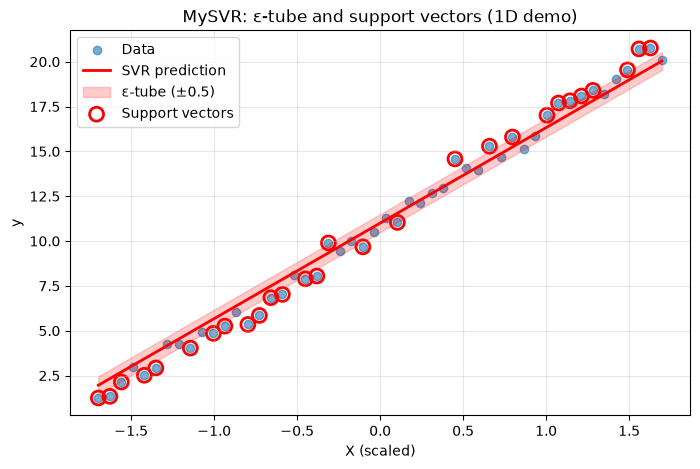

In [7]:
# Simple 1D demo to show the ε-tube
np.random.seed(42)
X_1d = np.linspace(0, 10, 50).reshape(-1, 1)
y_1d = 2 * X_1d.ravel() + 1 + np.random.normal(0, 0.5, 50)

scaler_1d = StandardScaler()
X_1d_s = scaler_1d.fit_transform(X_1d)

mine_1d = MySVR(C=10.0, epsilon=0.5, kernel='linear', lr=0.1, n_iters=5000).fit(X_1d_s, y_1d)
y_pred_1d = mine_1d.predict(X_1d_s)

plt.figure(figsize=(8, 5))
plt.scatter(X_1d_s, y_1d, alpha=0.6, label='Data')
plt.plot(X_1d_s, y_pred_1d, 'r-', linewidth=2, label='SVR prediction')
plt.fill_between(X_1d_s.ravel(),
                 y_pred_1d - mine_1d.epsilon,
                 y_pred_1d + mine_1d.epsilon,
                 alpha=0.2, color='red', label=f'ε-tube (±{mine_1d.epsilon})')
# Mark support vectors
plt.scatter(X_1d_s[mine_1d.support_], y_1d[mine_1d.support_],
            s=100, facecolors='none', edgecolors='red', linewidth=2,
            label='Support vectors')
plt.xlabel('X (scaled)')
plt.ylabel('y')
plt.title('MySVR: ε-tube and support vectors (1D demo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Summary & key takeaways

- SVR fits a line/curve with an **ε-tube**: errors inside the tube cost nothing.
- Only points outside the tube (**support vectors**) shape the model.
- Primal SGD on ε-insensitive loss: if |residual| > ε, move toward y; otherwise just shrink weights.
- **Scaling is MANDATORY** - kernels/ε-tube operate on distances.
- `C` = inverse regularization: small C = wide tube (more violations), large C = strict tube.
- `epsilon` = tube half-width: larger ε = fewer SVs, smoother fit.
- RBF kernel via Random Fourier Features: finite approximation of infinite-dimensional mapping.
- Our implementation captures the core SVR mechanics; sklearn's libsvm (SMO) is more efficient for production.